ДР 6. Группа 10. K-средних. Хуснутдинов Эдуард Ринатович. Нуман Ахмед. Эспиноза Ортис Хуан Карлос

ДЗ: Использовать и сравнить методы кластеризаци из раздела - K-средних, 
Иерархической кластеризации, с подбором параметров перебором по сетке. 
Оценкой качества: метод локтя, колена, силуэтов. Индекс Калински-Харабаса (Calinski-Harabasz Index). Индекс Дэвиса-Болдина (Davies-Bouldin Index)
Построить эти диаграммы для нескольких вариантов разбиения на кластера и сравнить. 2
Проанализировать лучшие параметры разбиения на кластера. 
Разобраться в природе каждого кластера и его закономерностях. 
Написать анализ по каждому графику и диаграмме в работе. 
Анализ пишите внутри блокнота в соответсвующем разделе + итоговые редультаты и выводы сформулируйте в конце блокнота.

# Анализ и кластеризация стран


Источник данных: все данные былы созданы на основе данных следующего источника: 
https://www.cia.gov/library/publications/the-world-factbook/docs/faqs.html

## Цель: 

### Найти похожие между собой страны и регионы, экспериментируя с различным количеством кластеров. <br><br> Что означают полученные кластеры? <br><br> *Замечание: в этой задаче нет 100% правильных ответов*

----

## Импорт библиотек и загрузка данных

**Задание: Запустите ячейки ниже для импорта библиотек и загрузки данных из файла в датайфрейм Pandas.**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('CIA_Country_Facts.csv')

## Исследование данных (Exploratory Data Analysis)

**Задание: посмотрите на строки и колонки в данных, в том числе на типы данных для колонок.**

In [3]:
# Напишите Ваш код в этой ячейке
df.head()

,Country,Region,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),Phones (per 1000),Arable (%),Crops (%),Other (%),Climate,Birthrate,Deathrate,Agriculture,Industry,Service
0,Afghanistan,ASIA (EX. NEAR EAST),31056997,647500,48.0,0.00,23.06,163.07,700.0,36.0,3.2,12.13,0.22,87.65,1.0,46.60,20.34,0.380,0.240,0.380
1,Albania,EASTERN EUROPE,3581655,28748,124.6,1.26,-4.93,21.52,4500.0,86.5,71.2,21.09,4.42,74.49,3.0,15.11,5.22,0.232,0.188,0.579
2,Algeria,NORTHERN AFRICA,32930091,2381740,13.8,0.04,-0.39,31.00,6000.0,70.0,78.1,3.22,0.25,96.53,1.0,17.14,4.61,0.101,0.600,0.298
3,American Samoa,OCEANIA,57794,199,290.4,58.29,-20.71,9.27,8000.0,97.0,259.5,10.00,15.00,75.00,2.0,22.46,3.27,NaN,NaN,NaN
4,Andorra,WESTERN EUROPE,71201,468,152.1,0.00,6.60,4.05,19000.0,100.0,497.2,2.22,0.00,97.78,3.0,8.71,6.25,NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 227 entries, 0 to 226
Data columns (total 20 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Country                             227 non-null    str    
 1   Region                              227 non-null    str    
 2   Population                          227 non-null    int64  
 3   Area (sq. mi.)                      227 non-null    int64  
 4   Pop. Density (per sq. mi.)          227 non-null    float64
 5   Coastline (coast/area ratio)        227 non-null    float64
 6   Net migration                       224 non-null    float64
 7   Infant mortality (per 1000 births)  224 non-null    float64
 8   GDP ($ per capita)                  226 non-null    float64
 9   Literacy (%)                        209 non-null    float64
 10  Phones (per 1000)                   223 non-null    float64
 11  Arable (%)                          225 non-null    floa

In [5]:
df.columns

Index(['Country', 'Region', 'Population', 'Area (sq. mi.)',
       'Pop. Density (per sq. mi.)', 'Coastline (coast/area ratio)',
       'Net migration', 'Infant mortality (per 1000 births)',
       'GDP ($ per capita)', 'Literacy (%)', 'Phones (per 1000)', 'Arable (%)',
       'Crops (%)', 'Other (%)', 'Climate', 'Birthrate', 'Deathrate',
       'Agriculture', 'Industry', 'Service'],
      dtype='str')

In [6]:
df.describe()

,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),Phones (per 1000),Arable (%),Crops (%),Other (%),Climate,Birthrate,Deathrate,Agriculture,Industry,Service
count,2.270000e+02,2.270000e+02,227.000000,227.000000,224.000000,224.000000,226.000000,209.000000,223.000000,225.000000,225.000000,225.000000,205.000000,224.000000,223.000000,212.000000,211.000000,212.000000
mean,2.874028e+07,5.982270e+05,379.047137,21.165330,0.038125,35.506964,9689.823009,82.838278,236.061435,13.797111,4.564222,81.638311,2.139024,22.114732,9.241345,0.150844,0.282711,0.565283
std,1.178913e+08,1.790282e+06,1660.185825,72.286863,4.889269,35.389899,10049.138513,19.722173,227.991829,13.040402,8.361470,16.140835,0.699397,11.176716,4.990026,0.146798,0.138272,0.165841
min,7.026000e+03,2.000000e+00,0.000000,0.000000,-20.990000,2.290000,500.000000,17.600000,0.200000,0.000000,0.000000,33.330000,1.000000,7.290000,2.290000,0.000000,0.020000,0.062000
25%,4.376240e+05,4.647500e+03,29.150000,0.100000,-0.927500,8.150000,1900.000000,70.600000,37.800000,3.220000,0.190000,71.650000,2.000000,12.672500,5.910000,0.037750,0.193000,0.429250
50%,4.786994e+06,8.660000e+04,78.800000,0.730000,0.000000,21.000000,5550.000000,92.500000,176.200000,10.420000,1.030000,85.700000,2.000000,18.790000,7.840000,0.099000,0.272000,0.571000
75%,1.749777e+07,4.418110e+05,190.150000,10.345000,0.997500,55.705000,15700.000000,98.000000,389.650000,20.000000,4.440000,95.440000,3.000000,29.820000,10.605000,0.221000,0.341000,0.678500
max,1.313974e+09,1.707520e+07,16271.500000,870.660000,23.060000,191.190000,55100.000000,100.000000,1035.600000,62.110000,50.680000,100.000000,4.000000,50.730000,29.740000,0.769000,0.906000,0.954000


# Визуализация данных

Давайте построим некоторые графики для визуализации данных. Кроме предложенных графиков ниже, Вы также можете создать любые дополнительные визуализации данных, которые покажутся Вам интересными!

**Задание: постройте гистограмму для колонки Population.**

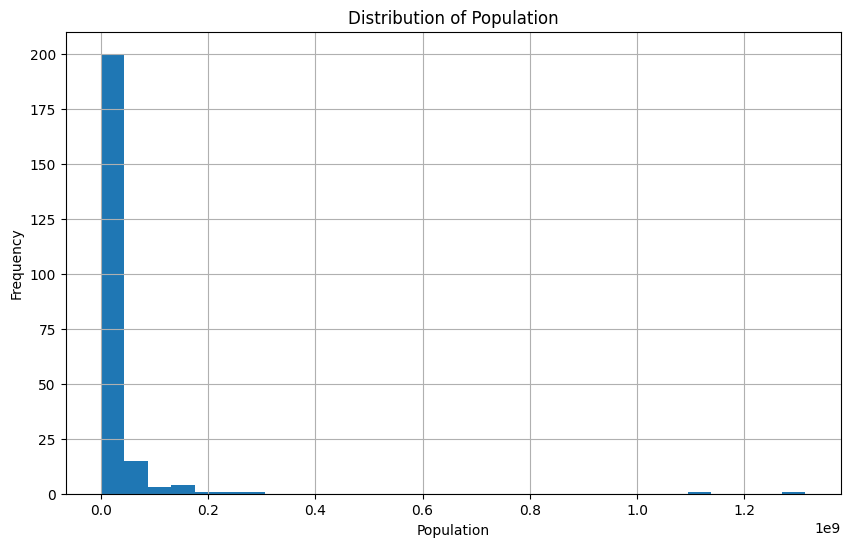

In [7]:
# Напишите Ваш код в этой ячейке
plt.figure(figsize=(10,6))
df['Population'].hist(bins=30)

plt.title('Distribution of Population')
plt.xlabel('Population')
plt.ylabel('Frequency')

plt.show()

Распределение признака Population сильно смещено вправо. Большинство стран имеют относительно небольшое население, тогда как небольшое количество стран (например, Китай и Индия) имеют чрезвычайно большое население. Это создает выбросы в данных.

**Задание: Вы заметите, что гистограмма очень перекошена из-за нескольких очень больших стран. Поменяйте график таким образом, чтобы показывать только страны с населением меньше 0.5 миллиарда людей.**

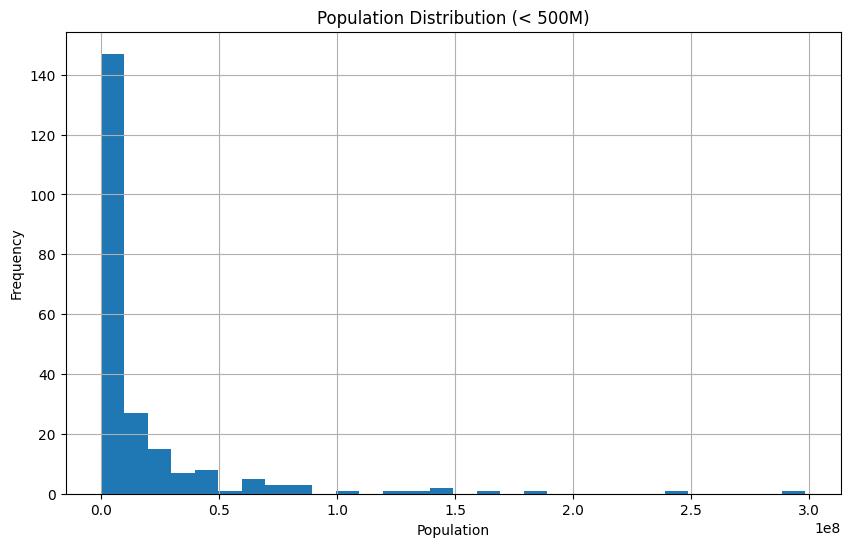

In [8]:
# Напишите Ваш код в этой ячейке
plt.figure(figsize=(10,6))

df[df['Population'] < 5e8]['Population'].hist(bins=30)

plt.title('Population Distribution (< 500M)')
plt.xlabel('Population')
plt.ylabel('Frequency')

plt.show()


Большинство стран имеют население менее 50 миллионов человек. Также наблюдается небольшое количество стран с более высоким населением, но их значительно меньше.

**Задание: далее исследуем GDP (ВВП - Валовый Внутренний Продукт) и регионы (Regions). Постройте график barchart, на котором изобразите среднее ВВП на душу населения (GDP per Capita) для каждого региона.**

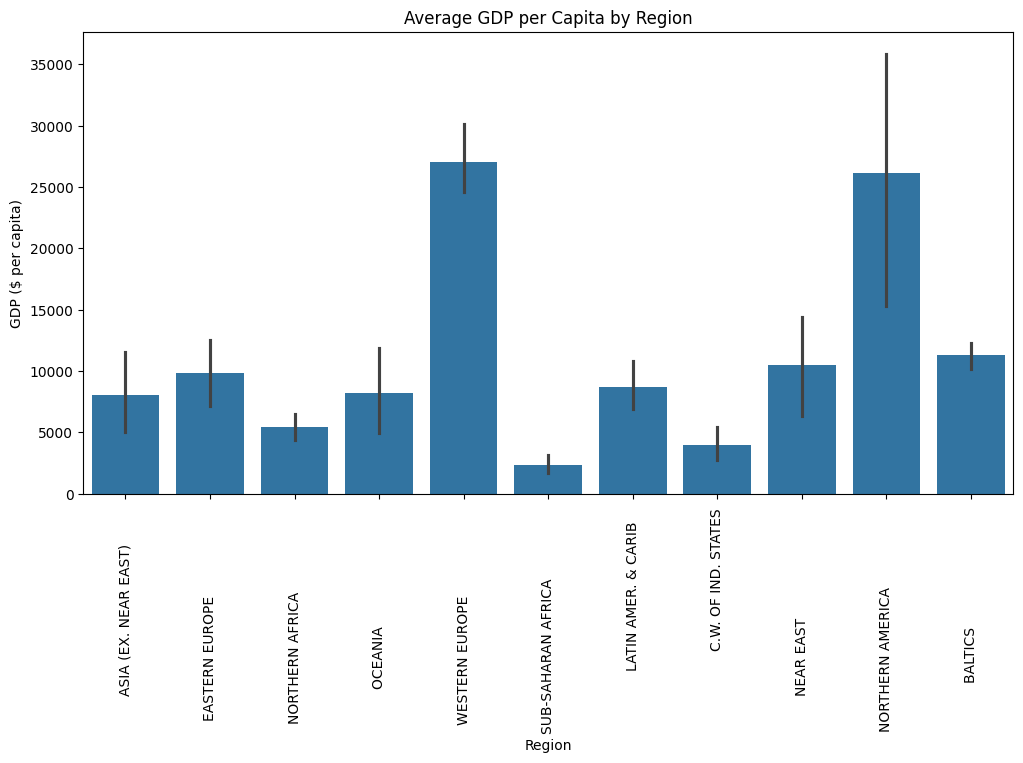

In [9]:
# Напишите Ваш код в этой ячейке
plt.figure(figsize=(12,6))

sns.barplot(
    x='Region',
    y='GDP ($ per capita)',
    data=df,
    estimator='mean'
)

plt.xticks(rotation=90)
plt.title('Average GDP per Capita by Region')

plt.show()


**Задание: Постройте график scatterplot для визуализации связи между колонками "кол-во телефонов на одну тысячу человек" и "ВВП на душу населения". Раскрасьте этот график разными цветами по колонке Region.**

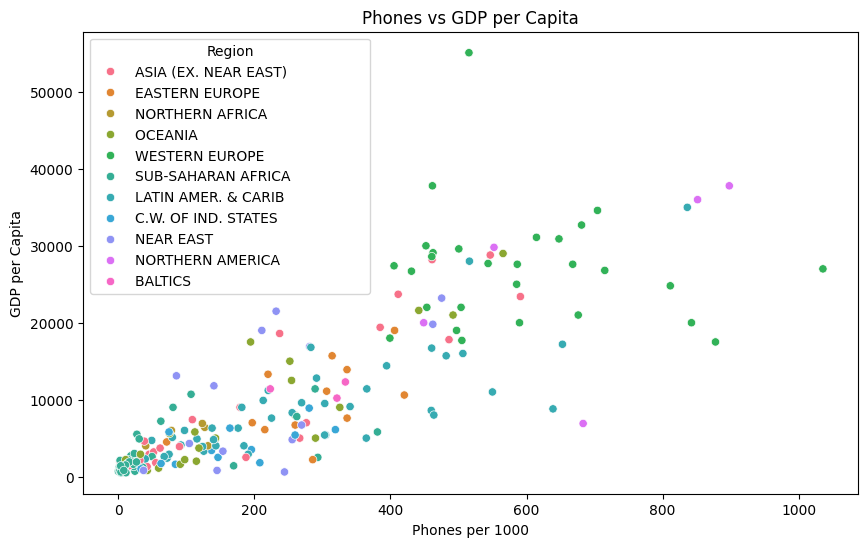

In [10]:
# Напишите Ваш код в этой ячейке
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Phones (per 1000)',
    y='GDP ($ per capita)',
    data=df,
    hue='Region'
)

plt.title('Phones vs GDP per Capita')
plt.xlabel('Phones per 1000')
plt.ylabel('GDP per Capita')

plt.show()


Мы наблюдаем совершенно нелинейную прямую зависимость между количеством телефонов и ВВП на душу населения.

**Задание: Постройте график scatterplot для колонок "GDP per Capita" и "Literacy" (раскрасьте график по колонке Region). Какие выводы можно сделать из этого графика?**

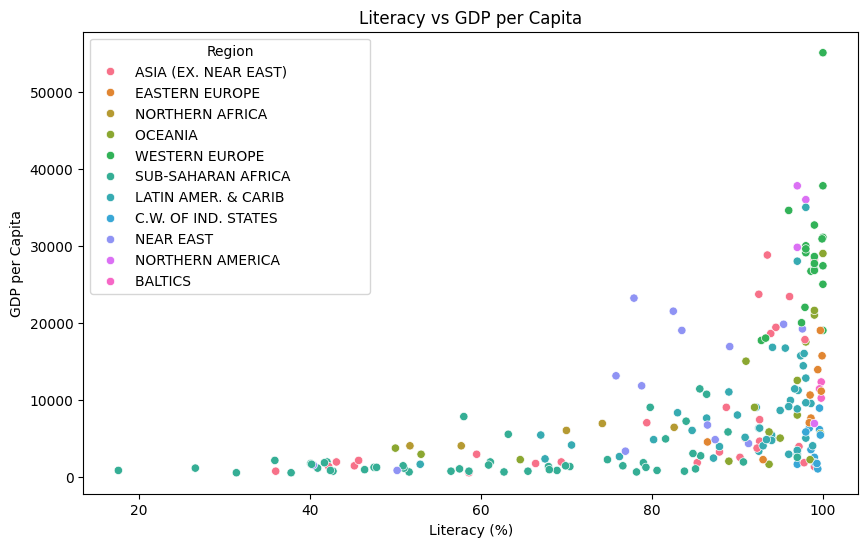

In [11]:
# Напишите Ваш код в этой ячейке
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Literacy (%)',
    y='GDP ($ per capita)',
    data=df,
    hue='Region'
)

plt.title('Literacy vs GDP per Capita')
plt.xlabel('Literacy (%)')
plt.ylabel('GDP per Capita')

plt.show()


**Задание: Постройте тепловую карту Heatmap для корреляций между колонками в датафрейме.**

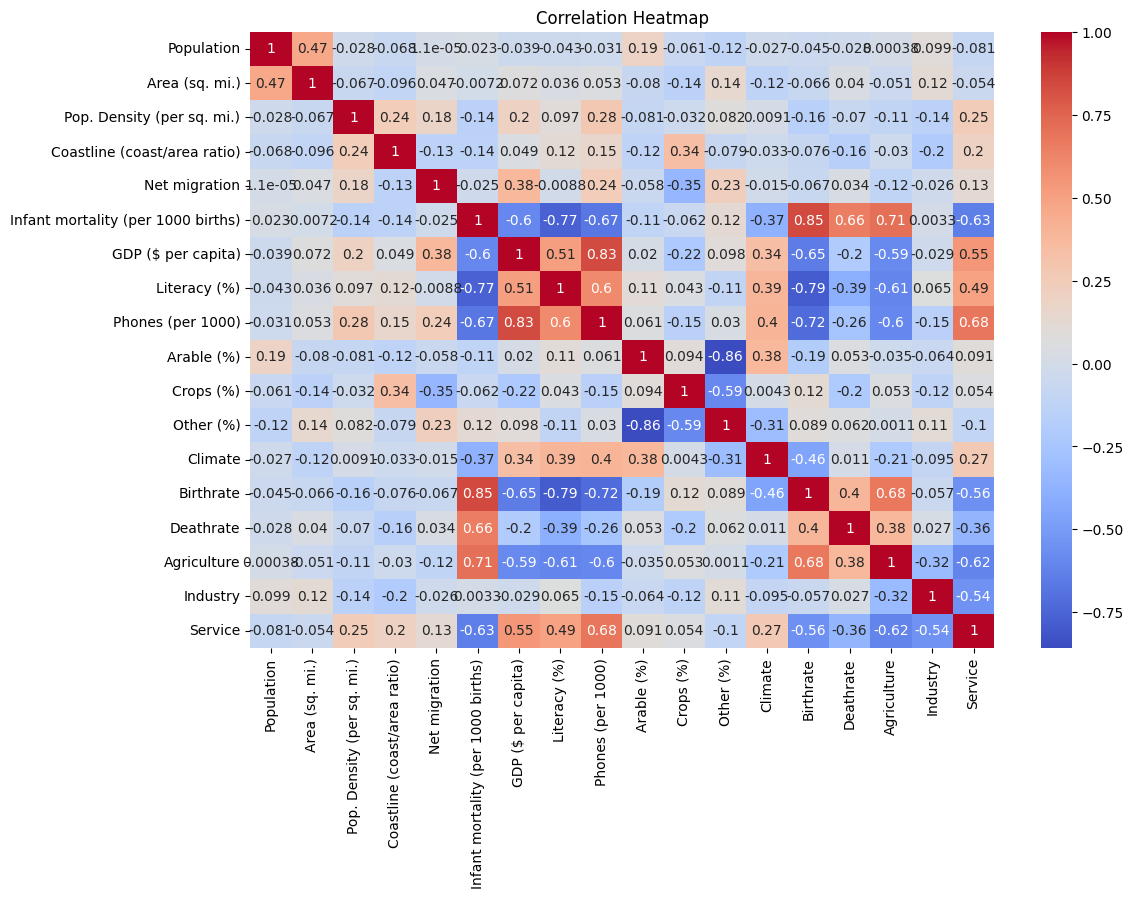

In [12]:
# Напишите Ваш код в этой ячейке
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

**Задание: Seaborn может автоматически выполнять иерархическую кластеризацию данных с помощью функции clustermap(). Постройте график clustermap для корреляций между колонками датафрейма.**

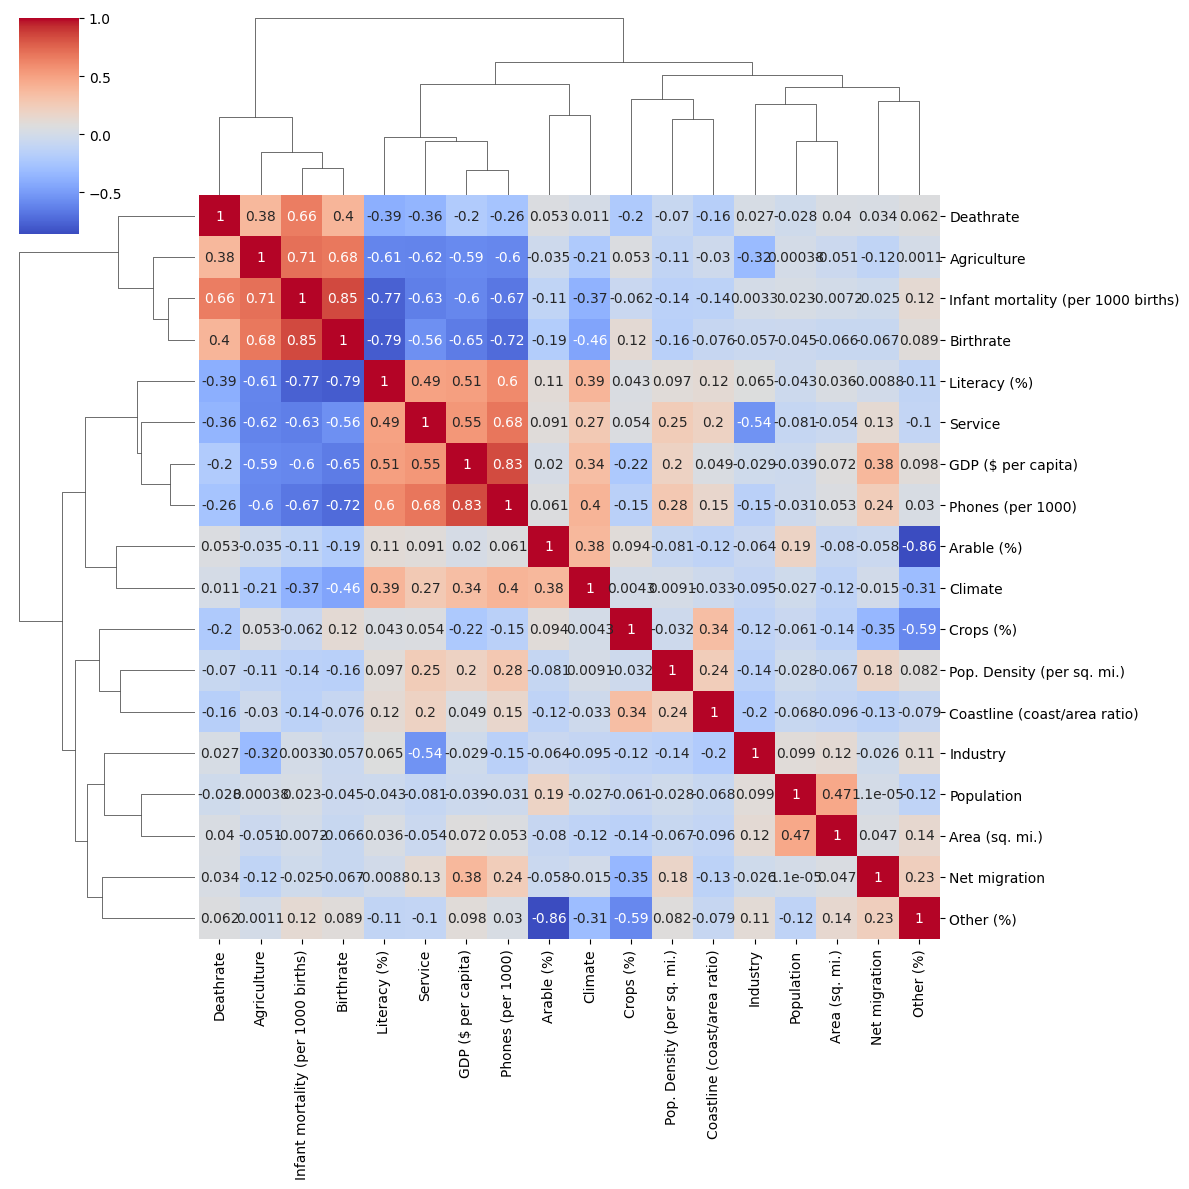

In [13]:
# Напишите Ваш код в этой ячейке
sns.clustermap(
    df.corr(numeric_only=True),
    cmap='coolwarm',
    annot=True,
    figsize=(12,12)
)


In [14]:
# Примените практику из иерархической кластеризации

-----

## Подготовка данных и модель данных

Давайте подготовим наши данные для кластеризации с помощью метода К-средних!

### Отсутствующие данные (Missing Data)

**Задание: Постройте отчёт - сколько строк имеют отсутствующие значения в той или иной колонке.**

In [15]:
# Напишите Ваш код в этой ячейке
df.isnull().sum()


Country                                0
Region                                 0
Population                             0
Area (sq. mi.)                         0
Pop. Density (per sq. mi.)             0
Coastline (coast/area ratio)           0
Net migration                          3
Infant mortality (per 1000 births)     3
GDP ($ per capita)                     1
Literacy (%)                          18
Phones (per 1000)                      4
Arable (%)                             2
Crops (%)                              2
Other (%)                              2
Climate                               22
Birthrate                              3
Deathrate                              4
Agriculture                           15
Industry                              16
Service                               15
dtype: int64

**Задание: Для каких стран в колонке Agriculture значения NaN? Что эти страны имеют общего между собой?**

In [16]:
df[df['Agriculture'].isnull()]['Country']

3            American Samoa
4                   Andorra
78                Gibraltar
80                Greenland
83                     Guam
134                 Mayotte
140              Montserrat
144                   Nauru
153      N. Mariana Islands
171            Saint Helena
174    St Pierre & Miquelon
177              San Marino
208       Turks & Caicos Is
221       Wallis and Futuna
223          Western Sahara
Name: Country, dtype: str

In [17]:
df[df['Agriculture'].isnull()][['Country', 'Region']]

,Country,Region
3,American Samoa,OCEANIA
4,Andorra,WESTERN EUROPE
78,Gibraltar,WESTERN EUROPE
80,Greenland,NORTHERN AMERICA
83,Guam,OCEANIA
134,Mayotte,SUB-SAHARAN AFRICA
140,Montserrat,LATIN AMER. & CARIB
144,Nauru,OCEANIA
153,N. Mariana Islands,OCEANIA
171,Saint Helena,SUB-SAHARAN AFRICA


**Задание: Вы наверняка заметили, что большинство этих стран являются маленькими островами, кроме Гринландии и Западной Сахары. Замените для этих стран отсутствующие значения нулями, потому что это очень маленькие страны. У Вас должно получиться 15 таких стран. В качестве подсказки вспомните, что мы можем применять вот такой синтаксис:**

    df[df['feature'].isnull()]
    

In [18]:
# Напишите Ваш код в этой ячейке
df.loc[df['Agriculture'].isnull(), 'Agriculture'] = 0


In [19]:
df['Agriculture'].isnull().sum()

np.int64(0)

**Задание: Проверьте заново, в каких колонках сколько строк имеют неопределённые значения:**

In [20]:
# Напишите Ваш код в этой ячейке
df.isnull().sum().sort_values(ascending=False)


Climate                               22
Literacy (%)                          18
Industry                              16
Service                               15
Deathrate                              4
Phones (per 1000)                      4
Infant mortality (per 1000 births)     3
Net migration                          3
Birthrate                              3
Other (%)                              2
Crops (%)                              2
Arable (%)                             2
GDP ($ per capita)                     1
Population                             0
Region                                 0
Country                                0
Area (sq. mi.)                         0
Pop. Density (per sq. mi.)             0
Coastline (coast/area ratio)           0
Agriculture                            0
dtype: int64

**Задание: Обратите внимание, что колонка "climate" пустая для нескольких стран. Но для всех стран заполнена колонка Region! Пользуясь этим, замените отсутствующие значения колонки Climate на средние значения этой колонки, где усреднение выполняется для соответствующего региона.**

Подсказка о том, как это можно сделать: https://stackoverflow.com/questions/19966018/pandas-filling-missing-values-by-mean-in-each-group


In [21]:
# Напишите Ваш код в этой ячейке
df['Climate'] = df.groupby('Region')['Climate'].transform(
    lambda x: x.fillna(x.mean())
)


In [22]:
df['Climate'].isnull().sum()

np.int64(0)

**Задание: Проверьте заново, сколько теперь отсутствующих значений.**

In [23]:
# Напишите Ваш код в этой ячейке

df.isnull().sum().sort_values(ascending=False)



Literacy (%)                          18
Industry                              16
Service                               15
Phones (per 1000)                      4
Deathrate                              4
Birthrate                              3
Infant mortality (per 1000 births)     3
Net migration                          3
Crops (%)                              2
Other (%)                              2
Arable (%)                             2
GDP ($ per capita)                     1
Area (sq. mi.)                         0
Population                             0
Region                                 0
Country                                0
Coastline (coast/area ratio)           0
Pop. Density (per sq. mi.)             0
Climate                                0
Agriculture                            0
dtype: int64

**Задание: Для колонки "Literacy percentage" примените такой же метод, что и ранее для колонки Climate. Замените отсутствующие значения колонки Literacy % на средние значения этой колонки для соответствующего региона.**

In [24]:
df['Literacy (%)'] = df.groupby('Region')['Literacy (%)'].transform(
    lambda x: x.fillna(x.mean())
)

In [25]:
# Напишите Ваш код в этой ячейке
df['Literacy (%)'].isnull().sum()


np.int64(0)

**Задание: Проверьте заново, сколько теперь отсутствующих значений.**

In [26]:
# Напишите Ваш код в этой ячейке

df.isnull().sum().sort_values(ascending=False)




Industry                              16
Service                               15
Deathrate                              4
Phones (per 1000)                      4
Birthrate                              3
Infant mortality (per 1000 births)     3
Net migration                          3
Arable (%)                             2
Crops (%)                              2
Other (%)                              2
GDP ($ per capita)                     1
Country                                0
Area (sq. mi.)                         0
Population                             0
Region                                 0
Coastline (coast/area ratio)           0
Literacy (%)                           0
Pop. Density (per sq. mi.)             0
Climate                                0
Agriculture                            0
dtype: int64

**Задание (Опционально): Теперь данные отсутствуют только для нескольких стран. Либо удалите такие страны, ИЛИ обработайте эти отсутствующие значения по какой-либо выбранной Вами методологии. Чтобы сэкономить Ваше время, мы удалим эти страны.**

In [27]:
# Напишите Ваш код в этой ячейке
df = df.dropna()


In [28]:
df.isnull().sum()

Country                               0
Region                                0
Population                            0
Area (sq. mi.)                        0
Pop. Density (per sq. mi.)            0
Coastline (coast/area ratio)          0
Net migration                         0
Infant mortality (per 1000 births)    0
GDP ($ per capita)                    0
Literacy (%)                          0
Phones (per 1000)                     0
Arable (%)                            0
Crops (%)                             0
Other (%)                             0
Climate                               0
Birthrate                             0
Deathrate                             0
Agriculture                           0
Industry                              0
Service                               0
dtype: int64

In [29]:
df.shape

(206, 20)

## Подготовка данных с признаками

**Задание: пришло время подготовить данные для кластеризации. Колонка Country является уникальным идентификатором, поэтому эта колонка не будет полезной для кластеризации, поскольку она содержит уникальные значения для каждой строки. При создании датафрейма с наборами признаков X удалите эту колонку Country.**

In [30]:
# Напишите Ваш код в этой ячейке
X = df.drop('Country', axis=1)
X.shape


(206, 19)

In [31]:
X.head()

,Region,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),Phones (per 1000),Arable (%),Crops (%),Other (%),Climate,Birthrate,Deathrate,Agriculture,Industry,Service
0,ASIA (EX. NEAR EAST),31056997,647500,48.0,0.00,23.06,163.07,700.0,36.0,3.2,12.13,0.22,87.65,1.000000,46.60,20.34,0.380,0.240,0.380
1,EASTERN EUROPE,3581655,28748,124.6,1.26,-4.93,21.52,4500.0,86.5,71.2,21.09,4.42,74.49,3.000000,15.11,5.22,0.232,0.188,0.579
2,NORTHERN AFRICA,32930091,2381740,13.8,0.04,-0.39,31.00,6000.0,70.0,78.1,3.22,0.25,96.53,1.000000,17.14,4.61,0.101,0.600,0.298
5,SUB-SAHARAN AFRICA,12127071,1246700,9.7,0.13,0.00,191.19,1900.0,42.0,7.8,2.41,0.24,97.35,1.885417,45.11,24.20,0.096,0.658,0.246
6,LATIN AMER. & CARIB,13477,102,132.1,59.80,10.76,21.03,8600.0,95.0,460.0,0.00,0.00,100.00,2.000000,14.17,5.34,0.040,0.180,0.780


**Задание: Создайте набор признаков X, причём колонка Region всё ещё является категориальной, поэтому для этой колонки создайте дамми-переменные с помощью Pandas.**

In [32]:
# Напишите Ваш код в этой ячейке
X = pd.get_dummies(df.drop('Country', axis=1), columns=['Region'], drop_first=True)


In [33]:
X.head()

,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),Phones (per 1000),Arable (%),...,Region_BALTICS,Region_C.W. OF IND. STATES,Region_EASTERN EUROPE,Region_LATIN AMER. & CARIB,Region_NEAR EAST,Region_NORTHERN AFRICA,Region_NORTHERN AMERICA,Region_OCEANIA,Region_SUB-SAHARAN AFRICA,Region_WESTERN EUROPE
0,31056997,647500,48.0,0.00,23.06,163.07,700.0,36.0,3.2,12.13,...,False,False,False,False,False,False,False,False,False,False
1,3581655,28748,124.6,1.26,-4.93,21.52,4500.0,86.5,71.2,21.09,...,False,False,True,False,False,False,False,False,False,False
2,32930091,2381740,13.8,0.04,-0.39,31.00,6000.0,70.0,78.1,3.22,...,False,False,False,False,False,True,False,False,False,False
5,12127071,1246700,9.7,0.13,0.00,191.19,1900.0,42.0,7.8,2.41,...,False,False,False,False,False,False,False,False,True,False
6,13477,102,132.1,59.80,10.76,21.03,8600.0,95.0,460.0,0.00,...,False,False,False,True,False,False,False,False,False,False


In [34]:
X.shape

(206, 28)

### Масштабирование данных

**Задание: Поскольку некоторые колонки измеряются в процентах, а некоторые в абсолютных значениях, то выполните масштабирование признаков с помощью Sklearn.**

In [35]:
# Напишите Ваш код в этой ячейке
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


In [36]:
X_scaled[:2]

array([[-4.49070574e-03,  3.54754710e-04, -1.91984323e-01,
        -2.41109465e-01,  5.06674155e+00,  3.49684160e+00,
        -8.71563662e-01, -2.40141348e+00, -1.01013218e+00,
        -1.60500576e-01, -5.17349264e-01,  3.96934869e-01,
        -1.65621236e+00,  2.13168269e+00,  2.14532664e+00,
         1.53929636e+00, -3.27778435e-01, -1.10519238e+00,
        -1.21566135e-01, -2.48708002e-01, -2.37508434e-01,
        -5.13618225e-01, -2.80239240e-01, -1.57720074e-01,
        -1.21566135e-01, -2.80239240e-01, -5.58660819e-01,
        -3.54518067e-01],
       [-2.27651435e-01, -3.31852574e-01, -1.33585223e-01,
        -2.23096935e-01, -1.06532787e+00, -4.41197969e-01,
        -4.93684939e-01,  1.93665842e-01, -6.91706815e-01,
         5.15828228e-01, -1.97664375e-02, -4.07504606e-01,
         1.17981913e+00, -6.55498484e-01, -8.28801116e-01,
         5.39507961e-01, -7.04028177e-01,  1.02684568e-01,
        -1.21566135e-01, -2.48708002e-01,  4.21037679e+00,
        -5.13618225e-01, -2.80

После масштабирования признаки имеют среднее значение около нуля и стандартное отклонение около единицы. Это позволяет алгоритму кластеризации учитывать все признаки равномерно.

### Создание и обучение модели Kmeans




**Задание: Напишите цикл for для создания и обучения нескольких моделей KMeans, проверяя количество кластеров K от 2 до 30. На каждом шаге цикла сохраняйте сумму квадратов расстояний от точек до центров кластеров (SSD - Sum of Squared Distances) для каждого значения K. Далее нанесите эти данные на график, изображая метрику SSD для различных значений К. Опционально: также можно построить график barplot с изменениями метрики SSD.**

In [37]:
# Напишите Ваш код в этой ячейке
from sklearn.cluster import KMeans

In [38]:
ssd = []

K_range = range(2, 31)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    ssd.append(model.inertia_)

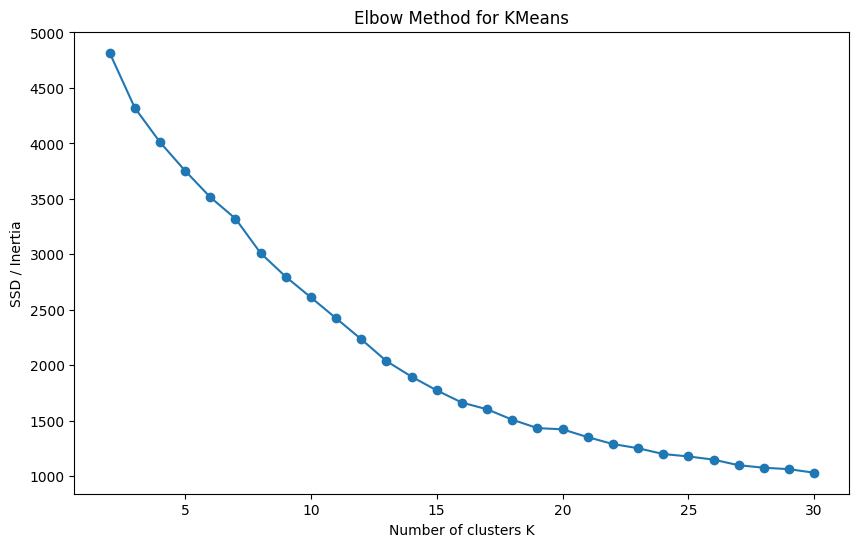

In [39]:
plt.figure(figsize=(10, 6))

plt.plot(K_range, ssd, marker='o')

plt.xlabel('Number of clusters K')
plt.ylabel('SSD / Inertia')
plt.title('Elbow Method for KMeans')

plt.show()

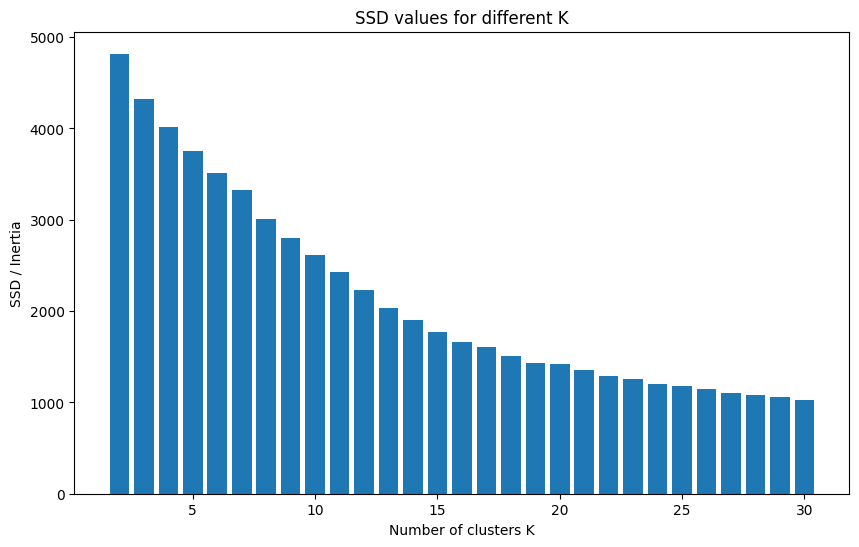

In [40]:
plt.figure(figsize=(10, 6))

plt.bar(K_range, ssd)

plt.xlabel('Number of clusters K')
plt.ylabel('SSD / Inertia')
plt.title('SSD values for different K')

plt.show()

In [41]:
# Выполните анализ данных с помощью иерархической кластеризации

-----

# Интерпретация модели


**Задание: Какое значение K может быть хорошим выбором? Возможно таких значений несколько? Какие признаки влияют на формирование этих кластеров? Поскольку это обучение без учителя (unsupervised learning), здесь нет на 100% правильного ответа. Можете посмотреть видео-лекцию с решениями, где мы обсуждаем эту тему.**

In [42]:
# Выберите K на основе метода локтя, а также посмотрите какие признаки влияют на создение кластеров!

# Помните, здесь нет на 100% правильного ответа!

Значение K не является однозначным. На основе метода локтя можно выбрать значения K ≈ 10–15, однако более интерпретируемым вариантом является K=3. В этом случае данные можно разделить на три группы: развитые страны с высоким уровнем ВВП и технологий, страны со средним уровнем развития и развивающиеся страны с низкими экономическими показателями.

-----


#### Пример: выбираем K=3

**Можно сказать, что в точке K=3 падение метрики SSD более пологое (хотя метрика продолжает уменьшаться после этой точки). Как может выглядеть картина для K=3? Давайте посмотрим, какие признаки являются важными в случае 3 кластеров!**

In [43]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters  

In [44]:
cluster_profile = df.groupby('Cluster').mean(numeric_only=True)
cluster_profile

,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),Phones (per 1000),Arable (%),Crops (%),Other (%),Climate,Birthrate,Deathrate,Agriculture,Industry,Service
Cluster,,,,,,,,,,,,,,,,,,
0,2.044269e+07,530778.923077,66.540385,0.533654,0.307692,87.687500,1875.000000,59.240385,15.686538,11.593846,2.438846,85.967692,1.812188,37.189231,15.703654,0.311019,0.271904,0.417231
1,2.065061e+07,627078.867925,745.560377,17.706415,2.441698,7.004717,22645.283019,98.068690,488.156604,20.385283,1.789245,77.825660,2.860437,10.845094,9.081321,0.040811,0.259057,0.700132
2,4.311025e+07,716962.396040,186.018812,24.833564,-1.576931,27.415644,6455.445545,86.777260,182.261386,12.410891,7.160792,80.427228,1.987789,21.085644,6.390099,0.128752,0.305970,0.564218


In [45]:
cluster_profile = df.groupby('Cluster').mean(numeric_only=True)
cluster_profile[['GDP ($ per capita)','Phones (per 1000)',
                 'Infant mortality (per 1000 births)',
                 'Literacy (%)','Birthrate','Agriculture','Service']]

,GDP ($ per capita),Phones (per 1000),Infant mortality (per 1000 births),Literacy (%),Birthrate,Agriculture,Service
Cluster,,,,,,,
0,1875.000000,15.686538,87.687500,59.240385,37.189231,0.311019,0.417231
1,22645.283019,488.156604,7.004717,98.068690,10.845094,0.040811,0.700132
2,6455.445545,182.261386,27.415644,86.777260,21.085644,0.128752,0.564218


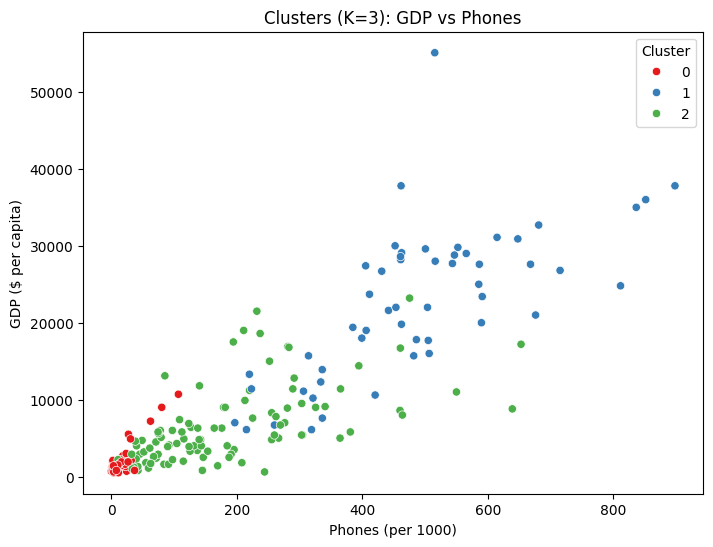

In [46]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='Phones (per 1000)',
    y='GDP ($ per capita)',
    hue='Cluster',
    data=df,
    palette='Set1'
)
plt.title('Clusters (K=3): GDP vs Phones')
plt.show()

При K=3 страны чётко разделяются на три группы. Первая группа включает развитые страны с высоким уровнем ВВП, высоким уровнем технологий и низкой рождаемостью. Вторая группа представляет развивающиеся страны с низкими экономическими показателями, высокой рождаемостью и высокой младенческой смертностью. Третья группа является промежуточной и включает страны со средним уровнем развития. Основными признаками, влияющими на формирование кластеров, являются ВВП на душу населения, количество телефонов, уровень рождаемости и младенческой смертности.

In [47]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

labels

array([0, 2, 2, 0, 2, 2, 2, 2, 1, 1, 1, 2, 2, 2, 2, 1, 1, 1, 2, 0, 1, 0,
       2, 1, 0, 2, 1, 2, 1, 0, 0, 0, 0, 0, 1, 2, 1, 0, 0, 2, 2, 2, 0, 0,
       0, 2, 0, 1, 2, 1, 1, 0, 2, 2, 2, 2, 2, 0, 0, 1, 0, 1, 2, 1, 1, 2,
       2, 0, 0, 2, 2, 1, 0, 1, 2, 2, 2, 0, 0, 2, 2, 2, 1, 1, 1, 2, 2, 2,
       2, 1, 1, 1, 1, 2, 1, 1, 2, 2, 0, 2, 2, 1, 2, 2, 0, 1, 2, 0, 0, 2,
       1, 1, 1, 1, 1, 0, 0, 2, 2, 0, 1, 2, 2, 0, 2, 2, 2, 2, 2, 2, 0, 0,
       0, 1, 2, 2, 1, 2, 0, 0, 1, 2, 0, 2, 2, 2, 2, 2, 2, 1, 1, 2, 2, 2,
       1, 2, 0, 2, 2, 2, 2, 2, 2, 0, 2, 0, 1, 1, 1, 2, 0, 0, 1, 2, 0, 2,
       0, 1, 1, 2, 1, 2, 0, 2, 0, 2, 2, 2, 2, 2, 2, 0, 2, 2, 1, 1, 2, 2,
       2, 2, 2, 2, 2, 0, 0, 0], dtype=int32)

In [48]:
df['K=3 Clusters'] = labels

In [49]:
corr = df.corr(numeric_only=True)['K=3 Clusters'].sort_values()
corr

Deathrate                            -0.730187
Infant mortality (per 1000 births)   -0.590587
Birthrate                            -0.470708
Agriculture                          -0.420579
Net migration                        -0.220796
Other (%)                            -0.116008
Arable (%)                           -0.021206
Climate                               0.002509
Pop. Density (per sq. mi.)            0.002845
Area (sq. mi.)                        0.041274
GDP ($ per capita)                    0.052878
Population                            0.082929
Industry                              0.118061
Coastline (coast/area ratio)          0.138570
Phones (per 1000)                     0.188418
Crops (%)                             0.258044
Service                               0.275603
Literacy (%)                          0.490929
Cluster                               1.000000
K=3 Clusters                          1.000000
Name: K=3 Clusters, dtype: float64

Корреляционный анализ показывает, что кластеры формируются на основе социально-экономических факторов. Высокие значения смертности, рождаемости и доли сельского хозяйства характерны для менее развитых стран, тогда как высокий уровень грамотности, услуг и технологий соответствует более развитым странам. Это подтверждает, что модель успешно выявила структуру развития стран.

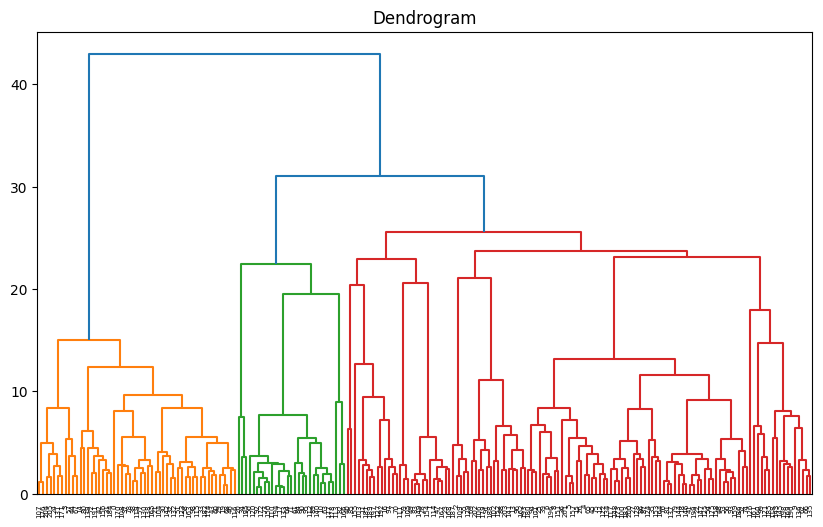

In [50]:
# Проанализируйте и сравните результаты К-средних и иерархической кластеризации
from scipy.cluster.hierarchy import linkage, dendrogram

linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10,6))
dendrogram(linked)
plt.title('Dendrogram')
plt.show()

In [51]:
from scipy.cluster.hierarchy import fcluster

hier_clusters = fcluster(linked, 3, criterion='maxclust')

In [52]:
df['Hierarchical'] = hier_clusters

Результаты K-средних и иерархической кластеризации в целом совпадают. Оба метода выявляют три основные группы стран, что подтверждается дендрограммой.

------------
-------------
## Географическая интерпретация модели

Результаты этой модели можно очень удобно визуализировать на географической карте! 

----
----

**Задание: Создайте кластеры для выбранного значения K. В нашем варианте решений мы думаем, что варианты K=3 или K=15 являются разумными вариантами. Но Вы можете попробовать и другие варианты для количества кластеров.**

In [53]:
kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster_3'] = kmeans_3.fit_predict(X_scaled)

In [54]:
kmeans_15 = KMeans(n_clusters=15, random_state=42, n_init=10)
df['Cluster_15'] = kmeans_15.fit_predict(X_scaled)

In [55]:
df[['Country', 'Cluster_3']].head()
# أو
df['Cluster_3'].value_counts()

Cluster_3
2    101
1     53
0     52
Name: count, dtype: int64

**Задание: А теперь представьте, что Ваш босс попросил Вас нанести эти страны и кластеры на географическую карту. Сможете ли Вы выяснить, как это делается? В качестве подсказки мы приводим шаги, а также пример того, как выглядит результат:**

1. Выясните, как можно установить библиотеку plotly: https://plotly.com/python/getting-started/

2. Выясните, как можно создать географическую карту choropleth map с помощью plotly: https://plotly.com/python/choropleth-maps/#using-builtin-country-and-state-geometries

3. Вам понадобятся ISO-коды. Либо возьмите их из Википедии, или используйте тот файл, который мы для Вас подготовили: **"../DATA/country_iso_codes.csv"**

4. С помощью номеров кластеров для стран, кодов ISO и названий стран постройте карту мира с помощью plotly.


**Замечание: Это задание моделирует ситуацию, с которой Вы можете столкнуться в работе. У Вас есть конкретная цель, и Вам нужно будет поработать с документацией, чтобы написать решение для этой задачи. Так что Вам нужно будет самостоятельно собрать решение из отдельных кусочков. Если у Вас что-то будет не получаться, то не волнуйтесь! Не стесняйтесь подглядывать в блокнот с решениями.**



In [56]:
import plotly

ModuleNotFoundError: No module named 'plotly'

In [ ]:
import plotly.express as px

In [ ]:
iso_codes = pd.read_csv("../DATA/country_iso_codes.csv")
iso_codes.head()

FileNotFoundError: [Errno 2] No such file or directory: '../DATA/country_iso_codes.csv'

In [ ]:
fig = px.choropleth(
    df,
    locations='Country',
    locationmode='country names',
    color='Cluster_3',
    hover_name='Country'
)
fig.show()

C:\Users\ahmad\AppData\Local\Temp\ipykernel_20040\1918794662.py:1: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


In [ ]:
fig = px.choropleth(
    df,
    locations='Country',
    locationmode='country names',
    color=df['Cluster_3'].astype(str),  # ← مهم
    hover_name='Country',
    color_discrete_sequence=px.colors.qualitative.Set1,
    title='World Clusters (K=3)'
)
fig.show()

C:\Users\ahmad\AppData\Local\Temp\ipykernel_20040\1744912679.py:1: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



---